# SmartFeed — NIR forage chemometrics (public spectra)

This notebook trains **spectrum → nutrient** models on a **real paired NIR dataset**.

**Data:** Marcondes et al. (2025), 291 dried/ground tropical forages from Brazil
(*Urochloa*, *Megathyrsus*, *Pennisetum*). Portable ITPhotonics poliSPECNIR,
absorbance ≈ **890–1707 nm** (256 bands), plus wet-lab CP, NDF, ADF.
CC BY 4.0. [figshare 28734674](https://doi.org/10.6084/m9.figshare.28734674)

**This is not Indian cattle feed.** Do not score mustard cake, wheat bran, or
BIS compounded mash with this joblib. The point is to show the pipeline you
would run after you collect Indian bag/pit scans + lab labels.

Name-lookup stays in `notebooks/ml/nutrition_estimator.ipynb`.


## 1. Setup


In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from sklearn.base import clone
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, LeaveOneGroupOut, cross_val_predict
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 120)
plt.rcParams.update(
    {
        "figure.figsize": (8.6, 4.2),
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

ROOT = Path("../..").resolve()
if not (ROOT / "data" / "processed" / "nir").exists():
    ROOT = Path(".").resolve()
    while ROOT != ROOT.parent and not (ROOT / "data" / "processed" / "nir").exists():
        ROOT = ROOT.parent

DATA = ROOT / "data" / "processed" / "nir" / "marcondes_2025_tropical_forage_joined.csv"
NB_DIR = Path(".").resolve()
if NB_DIR.name != "nir":
    NB_DIR = ROOT / "notebooks" / "nir"
ARTIFACTS = NB_DIR / "artifacts"
ARTIFACTS.mkdir(parents=True, exist_ok=True)
print("Data:", DATA)
print("Artifacts:", ARTIFACTS)


Data: /Users/sayangarai/Documents/Programming/Projects/SIH_PS_260111/data/processed/nir/marcondes_2025_tropical_forage_joined.csv
Artifacts: /Users/sayangarai/Documents/Programming/Projects/SIH_PS_260111/notebooks/nir/artifacts


## 2. Load paired spectra + lab values

If the processed CSV is missing, rebuild it from the figshare workbook:

`python data/build_nir_tables.py`


In [2]:
df = pd.read_csv(DATA)
wave_cols = [c for c in df.columns if c.startswith("a_")]
wavelengths = np.array([float(c[2:]) for c in wave_cols])
X_raw = df[wave_cols].to_numpy(dtype=float)
groups = df["species_code"].to_numpy()

print(df[["sample_id", "species", "cp_pct", "ndf_pct", "adf_pct"]].head())
print()
print(df.groupby("species")[["cp_pct", "ndf_pct", "adf_pct"]].agg(["count", "mean", "std"]).round(2))
print()
print(f"n={len(df)}  bands={len(wave_cols)}  {wavelengths.min():.1f}–{wavelengths.max():.1f} nm")
print(df[["cp_pct", "ndf_pct", "adf_pct"]].describe().round(2))


  sample_id                          species     cp_pct    ndf_pct    adf_pct
0     MOM_1  Megathyrsus maximus cv. Mombaça  15.541579  67.392509  33.373774
1     MOM_2  Megathyrsus maximus cv. Mombaça  15.728074  66.616746  34.514456
2     MOM_3  Megathyrsus maximus cv. Mombaça  12.726122  63.935087  31.955431
3     MOM_4  Megathyrsus maximus cv. Mombaça  14.678051  67.505389  29.734446
4     MOM_5  Megathyrsus maximus cv. Mombaça  12.632029  61.716937  29.562369

                                 cp_pct              ndf_pct              adf_pct             
                                  count   mean   std   count   mean   std   count   mean   std
species                                                                                       
Megathyrsus maximus cv. Massai       28  12.56  2.70      28  65.21  3.42      28  31.49  2.98
Megathyrsus maximus cv. Miyagui      28  14.66  2.80      28  62.62  3.51      28  28.93  2.07
Megathyrsus maximus cv. Mombaça      32  12.25  2.59    

## 3. Mean spectra and CP spread


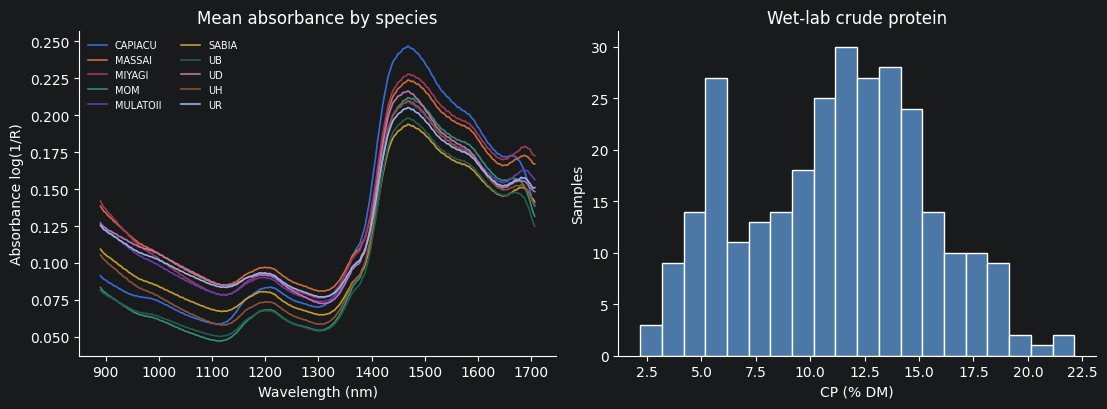

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2))
for code, sub in df.groupby("species_code"):
    axes[0].plot(wavelengths, sub[wave_cols].mean(), label=code, lw=1.2)
axes[0].set_title("Mean absorbance by species")
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Absorbance log(1/R)")
axes[0].legend(fontsize=7, ncol=2, frameon=False)

axes[1].hist(df["cp_pct"], bins=20, color="#4C78A8", edgecolor="white")
axes[1].set_title("Wet-lab crude protein")
axes[1].set_xlabel("CP (% DM)")
axes[1].set_ylabel("Samples")
fig.tight_layout()
fig.savefig(ARTIFACTS / "spectra_and_cp.png", dpi=140, bbox_inches="tight")
plt.show()


## 4. Preprocess

Chemometrics default: **SNV** (row-wise scatter correction), then optional
Savitzky–Golay 1st derivative. Do not StandardScaler the raw spectra across
samples before SNV — that mixes scatter with chemistry.


In [4]:
def snv(X: np.ndarray) -> np.ndarray:
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True)
    sd[sd == 0] = 1.0
    return (X - mu) / sd


def savgol1(X: np.ndarray) -> np.ndarray:
    return savgol_filter(X, window_length=11, polyorder=2, deriv=1, axis=1)


X_snv = snv(X_raw)
X_sg = savgol1(X_snv)
print("SNV shape", X_snv.shape, "SG1 shape", X_sg.shape)


SNV shape (291, 256) SG1 shape (291, 256)


## 5. Compare models

**Leave-one-species-out** is the honest score (can this calibration transfer
to an unseen grass?). Shuffled 5-fold is the optimistic in-matrix score.

ANN is included because it was requested. On this size of table, PLS usually wins.


In [5]:
def evaluate(name, estimator, X, y, groups):
    logo = LeaveOneGroupOut()
    pred_logo = cross_val_predict(clone(estimator), X, y, cv=logo, groups=groups)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    pred_kf = cross_val_predict(clone(estimator), X, y, cv=kf)
    row = {
        "model": name,
        "logo_mae": float(mean_absolute_error(y, pred_logo)),
        "logo_r2": float(r2_score(y, pred_logo)),
        "kfold_mae": float(mean_absolute_error(y, pred_kf)),
        "kfold_r2": float(r2_score(y, pred_kf)),
        "pred_logo": pred_logo,
    }
    print(
        f"{name:28s}  LOGO MAE {row['logo_mae']:.3f}  R2 {row['logo_r2']:.3f}  |  "
        f"5-fold MAE {row['kfold_mae']:.3f}  R2 {row['kfold_r2']:.3f}"
    )
    return row


def mean_baseline(y, groups):
    pred = np.zeros_like(y, dtype=float)
    for train, test in LeaveOneGroupOut().split(y, y, groups):
        pred[test] = y[train].mean()
    print(
        f"{'Train-mean baseline':28s}  LOGO MAE {mean_absolute_error(y, pred):.3f}  "
        f"R2 {r2_score(y, pred):.3f}"
    )
    return pred


y_cp = df["cp_pct"].to_numpy(dtype=float)
print("=== Crude protein (% DM) ===")
mean_baseline(y_cp, groups)

cp_rows = []
for n in (6, 8, 10, 12, 15):
    cp_rows.append(evaluate(f"PLS{n} + SNV", PLSRegression(n_components=n, scale=True), X_snv, y_cp, groups))
cp_rows.append(evaluate("PLS8 + SNV + SG1", PLSRegression(n_components=8, scale=True), X_sg, y_cp, groups))
cp_rows.append(evaluate("Ridge + SNV", Ridge(alpha=1.0), X_snv, y_cp, groups))
cp_rows.append(
    evaluate(
        "ANN MLP(64,32) + SNV",
        Pipeline(
            [
                ("scale", StandardScaler()),
                (
                    "mlp",
                    MLPRegressor(
                        hidden_layer_sizes=(64, 32),
                        max_iter=800,
                        random_state=42,
                        early_stopping=True,
                        validation_fraction=0.15,
                    ),
                ),
            ]
        ),
        X_snv,
        y_cp,
        groups,
    )
)

cp_table = pd.DataFrame([{k: v for k, v in r.items() if k != "pred_logo"} for r in cp_rows])
cp_winner = min(cp_rows, key=lambda r: r["logo_mae"])
print("\nCP winner:", cp_winner["model"], "LOGO MAE", round(cp_winner["logo_mae"], 3))
cp_table


=== Crude protein (% DM) ===
Train-mean baseline           LOGO MAE 3.826  R2 -0.241
PLS6 + SNV                    LOGO MAE 1.721  R2 0.692  |  5-fold MAE 1.486  R2 0.754
PLS8 + SNV                    LOGO MAE 1.436  R2 0.740  |  5-fold MAE 1.246  R2 0.784
PLS10 + SNV                   LOGO MAE 1.536  R2 0.712  |  5-fold MAE 1.153  R2 0.796
PLS12 + SNV                   LOGO MAE 1.600  R2 0.721  |  5-fold MAE 1.172  R2 0.806
PLS15 + SNV                   LOGO MAE 1.916  R2 0.627  |  5-fold MAE 1.338  R2 0.780
PLS8 + SNV + SG1              LOGO MAE 1.385  R2 0.753  |  5-fold MAE 1.197  R2 0.789
Ridge + SNV                   LOGO MAE 1.995  R2 0.642  |  5-fold MAE 1.662  R2 0.713
ANN MLP(64,32) + SNV          LOGO MAE 2.079  R2 0.545  |  5-fold MAE 1.977  R2 0.510

CP winner: PLS8 + SNV + SG1 LOGO MAE 1.385


,model,logo_mae,logo_r2,kfold_mae,kfold_r2
0,PLS6 + SNV,1.720771,0.691699,1.485816,0.753761
1,PLS8 + SNV,1.436110,0.739692,1.246142,0.784363
2,PLS10 + SNV,1.536240,0.711844,1.152883,0.795643
3,PLS12 + SNV,1.599815,0.720883,1.171518,0.805502
4,PLS15 + SNV,1.915535,0.627192,1.337892,0.779669
5,PLS8 + SNV + SG1,1.385054,0.753358,1.197096,0.788802
6,Ridge + SNV,1.995269,0.641589,1.661580,0.713358
7,"ANN MLP(64,32) + SNV",2.079324,0.545490,1.977119,0.509773


In [6]:
print("=== NDF (% DM) ===")
y_ndf = df["ndf_pct"].to_numpy(dtype=float)
mean_baseline(y_ndf, groups)
ndf_rows = []
for n in (6, 8, 10, 12):
    ndf_rows.append(evaluate(f"PLS{n} + SNV", PLSRegression(n_components=n, scale=True), X_snv, y_ndf, groups))
ndf_winner = min(ndf_rows, key=lambda r: r["logo_mae"])
print("\nNDF winner:", ndf_winner["model"], "LOGO MAE", round(ndf_winner["logo_mae"], 3))

print("\n=== ADF (% DM) ===")
y_adf = df["adf_pct"].to_numpy(dtype=float)
mean_baseline(y_adf, groups)
adf_rows = []
for n in (6, 8, 10, 12):
    adf_rows.append(evaluate(f"PLS{n} + SNV", PLSRegression(n_components=n, scale=True), X_snv, y_adf, groups))
adf_winner = min(adf_rows, key=lambda r: r["logo_mae"])
print("\nADF winner:", adf_winner["model"], "LOGO MAE", round(adf_winner["logo_mae"], 3))


=== NDF (% DM) ===
Train-mean baseline           LOGO MAE 6.741  R2 -0.213
PLS6 + SNV                    LOGO MAE 4.803  R2 0.252  |  5-fold MAE 3.460  R2 0.565
PLS8 + SNV                    LOGO MAE 3.788  R2 0.501  |  5-fold MAE 2.837  R2 0.670
PLS10 + SNV                   LOGO MAE 3.885  R2 0.488  |  5-fold MAE 2.955  R2 0.672
PLS12 + SNV                   LOGO MAE 3.872  R2 0.484  |  5-fold MAE 2.930  R2 0.667

NDF winner: PLS8 + SNV LOGO MAE 3.788

=== ADF (% DM) ===
Train-mean baseline           LOGO MAE 5.346  R2 -0.232
PLS6 + SNV                    LOGO MAE 3.507  R2 0.366  |  5-fold MAE 2.462  R2 0.641
PLS8 + SNV                    LOGO MAE 2.561  R2 0.607  |  5-fold MAE 1.808  R2 0.756
PLS10 + SNV                   LOGO MAE 2.733  R2 0.558  |  5-fold MAE 1.802  R2 0.758
PLS12 + SNV                   LOGO MAE 2.957  R2 0.504  |  5-fold MAE 1.963  R2 0.723

ADF winner: PLS8 + SNV LOGO MAE 2.561


## 6. Predicted vs lab (CP, leave-one-species-out)


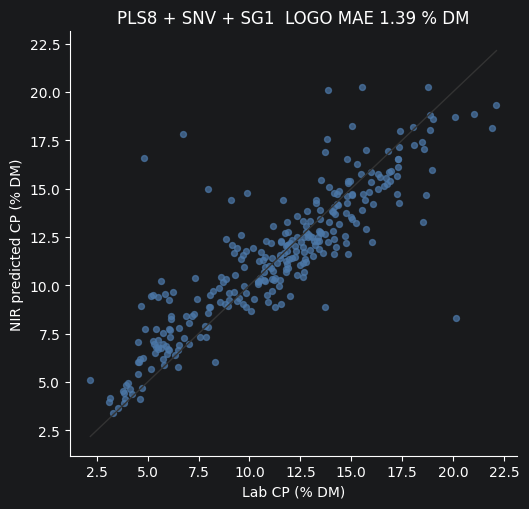

In [7]:
fig, ax = plt.subplots(figsize=(5.4, 5.2))
lo, hi = y_cp.min(), y_cp.max()
ax.scatter(y_cp, cp_winner["pred_logo"], s=18, alpha=0.7, c="#4C78A8")
ax.plot([lo, hi], [lo, hi], color="#333", lw=1)
ax.set_xlabel("Lab CP (% DM)")
ax.set_ylabel("NIR predicted CP (% DM)")
ax.set_title(cp_winner["model"] + f"  LOGO MAE {cp_winner['logo_mae']:.2f} % DM")
fig.tight_layout()
fig.savefig(ARTIFACTS / "cp_pred_vs_lab.png", dpi=140, bbox_inches="tight")
plt.show()


## 7. Fit winners on all rows and predict

`predict(absorbance)` expects 256 values on the same wavelength grid.
It will not accept a phone photo or a moisture %.


In [8]:
import re

def n_components(name: str) -> int:
    match = re.search(r"PLS(\d+)", name)
    return int(match.group(1)) if match else 8


def matrix_for(name: str) -> np.ndarray:
    return X_sg if "SG1" in name else X_snv


def transform_spectrum(absorbance, name: str) -> np.ndarray:
    vec = np.asarray(absorbance, dtype=float).reshape(1, -1)
    if vec.shape[1] != len(wave_cols):
        raise ValueError(f"Need {len(wave_cols)} absorbance values, got {vec.shape[1]}")
    xs = snv(vec)
    if "SG1" in name:
        xs = savgol1(xs)
    return xs


cp_model = PLSRegression(n_components=n_components(cp_winner["model"]), scale=True).fit(
    matrix_for(cp_winner["model"]), y_cp
)
ndf_model = PLSRegression(n_components=n_components(ndf_winner["model"]), scale=True).fit(
    matrix_for(ndf_winner["model"]), y_ndf
)
adf_model = PLSRegression(n_components=n_components(adf_winner["model"]), scale=True).fit(
    matrix_for(adf_winner["model"]), y_adf
)


def predict(absorbance) -> dict:
    """Predict CP / NDF / ADF from one absorbance spectrum (256 bands, 890–1707 nm)."""
    return {
        "cp_pct_dm": float(cp_model.predict(transform_spectrum(absorbance, cp_winner["model"])).ravel()[0]),
        "ndf_pct_dm": float(ndf_model.predict(transform_spectrum(absorbance, ndf_winner["model"])).ravel()[0]),
        "adf_pct_dm": float(adf_model.predict(transform_spectrum(absorbance, adf_winner["model"])).ravel()[0]),
        "matrix": "Brazilian tropical forage (Marcondes 2025) — not Indian cattle feed",
    }


demo = df.iloc[0]
print(demo[["sample_id", "species", "cp_pct", "ndf_pct", "adf_pct"]].to_dict())
print("NIR predict:", {k: round(v, 2) if isinstance(v, float) else v for k, v in predict(demo[wave_cols]).items()})


{'sample_id': 'MOM_1', 'species': 'Megathyrsus maximus cv. Mombaça', 'cp_pct': 15.541578953266797, 'ndf_pct': 67.39250883269777, 'adf_pct': 33.37377433047652}
NIR predict: {'cp_pct_dm': 19.8, 'ndf_pct_dm': 60.95, 'adf_pct_dm': 29.21, 'matrix': 'Brazilian tropical forage (Marcondes 2025) — not Indian cattle feed'}


## 8. Save artifacts


In [9]:
bundle = {
    "wavelengths_nm": wavelengths.tolist(),
    "cp_preprocess": "snv+sg1" if "SG1" in cp_winner["model"] else "snv",
    "ndf_preprocess": "snv+sg1" if "SG1" in ndf_winner["model"] else "snv",
    "adf_preprocess": "snv+sg1" if "SG1" in adf_winner["model"] else "snv",
    "cp_model": cp_model,
    "ndf_model": ndf_model,
    "adf_model": adf_model,
    "cp_winner": cp_winner["model"],
    "ndf_winner": ndf_winner["model"],
    "adf_winner": adf_winner["model"],
    "disclaimer": (
        "Calibrated on Brazilian tropical forage NIR (Marcondes 2025). "
        "Do not use on Indian oilcakes, bran, silage, or compounded cattle feed."
    ),
}
model_path = ARTIFACTS / "nir_forage_estimator.joblib"
joblib.dump(bundle, model_path)

report = {
    "source": "https://doi.org/10.6084/m9.figshare.28734674",
    "n_samples": int(len(df)),
    "n_wavelengths": int(len(wave_cols)),
    "wavelength_nm_min": float(wavelengths.min()),
    "wavelength_nm_max": float(wavelengths.max()),
    "cv": "leave_one_species_out",
    "cp": {
        "winner": cp_winner["model"],
        "logo_mae": cp_winner["logo_mae"],
        "logo_r2": cp_winner["logo_r2"],
        "kfold_mae": cp_winner["kfold_mae"],
        "unit": "% DM",
    },
    "ndf": {
        "winner": ndf_winner["model"],
        "logo_mae": ndf_winner["logo_mae"],
        "logo_r2": ndf_winner["logo_r2"],
        "unit": "% DM",
    },
    "adf": {
        "winner": adf_winner["model"],
        "logo_mae": adf_winner["logo_mae"],
        "logo_r2": adf_winner["logo_r2"],
        "unit": "% DM",
    },
    "ann_cp_logo_mae": next(r["logo_mae"] for r in cp_rows if r["model"].startswith("ANN")),
    "name_model_cp_mae_for_comparison": 5.111,
    "disclaimer": bundle["disclaimer"],
    "artifact": str(model_path.relative_to(ROOT)),
}
(ARTIFACTS / "metrics.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
print(json.dumps(report, indent=2))
print("Saved", model_path)


{
  "source": "https://doi.org/10.6084/m9.figshare.28734674",
  "n_samples": 291,
  "n_wavelengths": 256,
  "wavelength_nm_min": 889.995,
  "wavelength_nm_max": 1707.108,
  "cv": "leave_one_species_out",
  "cp": {
    "winner": "PLS8 + SNV + SG1",
    "logo_mae": 1.3850536483130576,
    "logo_r2": 0.753358299598746,
    "kfold_mae": 1.197096191518099,
    "unit": "% DM"
  },
  "ndf": {
    "winner": "PLS8 + SNV",
    "logo_mae": 3.787922373676091,
    "logo_r2": 0.5013983420824842,
    "unit": "% DM"
  },
  "adf": {
    "winner": "PLS8 + SNV",
    "logo_mae": 2.5608423329365686,
    "logo_r2": 0.6067418842578143,
    "unit": "% DM"
  },
  "ann_cp_logo_mae": 2.079323785825686,
  "name_model_cp_mae_for_comparison": 5.111,
  "disclaimer": "Calibrated on Brazilian tropical forage NIR (Marcondes 2025). Do not use on Indian oilcakes, bran, silage, or compounded cattle feed.",
  "artifact": "notebooks/nir/artifacts/nir_forage_estimator.joblib"
}
Saved notebooks/nir/artifacts/nir_forage_estima

## 9. What this does and does not prove

| Result | Meaning |
|---|---|
| CP LOGO MAE ≈ 1.4 % DM | Real NIR + lab labels beat the 5.1 % name-only model |
| ANN lost to PLS | 291 forage rows are a chemometrics problem, not a deep-net problem |
| Leave-one-species-out | Transfer across grasses is harder than shuffled 5-fold |
| Indian bags | Still unmeasured. Recollect on your instrument and matrix |

Harvard CIAT *Urochloa humidicola* (1,112 samples, 400–2498 nm) is larger, but
the Dataverse file needs a guestbook, so it is not in this folder.
